In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

from data_loader import load_brent_prices, load_events

plt.rcParams["figure.figsize"] = (14, 6)

df = load_brent_prices("../data/BrentOilPrices.csv")
events_df = load_events("../data/events.csv")

print("PyMC version:", pm.__version__)
print("Data shape:", df.shape)
print("Date range:", df["Date"].min(), "to", df["Date"].max())

g++ not available, if using conda: `conda install gxx`


PyMC version: 6.1.0
Data shape: (9011, 2)
Date range: 1987-05-20 00:00:00 to 2022-11-14 00:00:00


In [2]:
n_days = len(df)
prices = df["Price"].values

with pm.Model() as changepoint_model:
    # Discrete uniform prior over every possible day as the switch point
    tau = pm.DiscreteUniform("tau", lower=0, upper=n_days - 1)

    # "Before" and "after" mean price parameters
    mu1 = pm.Normal("mu1", mu=prices.mean(), sigma=prices.std())
    mu2 = pm.Normal("mu2", mu=prices.mean(), sigma=prices.std())

    # Shared standard deviation (simple model changing only the mean, per assignment spec)
    sigma = pm.HalfNormal("sigma", sigma=prices.std())

    # Switch function: select mu1 before tau, mu2 after
    idx = np.arange(n_days)
    mu = pm.math.switch(tau >= idx, mu1, mu2)

    # Likelihood connecting the model to observed prices
    likelihood = pm.Normal("obs", mu=mu, sigma=sigma, observed=prices)

print("Model defined successfully.")
print(changepoint_model)

Model defined successfully.


In [4]:
with changepoint_model:
    trace = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        cores=1,
        target_accept=0.9,
        random_seed=42,
        return_inferencedata=True,
    )

print("Sampling complete.")

Sequential sampling (4 chains in 1 job)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu1, mu2, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 16 seconds.


Sampling complete.


In [5]:
summary = az.summary(trace, var_names=["tau", "mu1", "mu2", "sigma"])
print(summary)

         mean     sd eti89_lb eti89_ub  ess_bulk  ess_tail r_hat mcse_mean  \
tau      4520    3.2     4500     4500       941       934  1.00       0.1   
mu1    21.419  0.286       21       22      4157      2751  1.00    0.0044   
mu2      75.6  0.275       75       76      3500      2690  1.00    0.0046   
sigma  18.593  0.138       18       19      3431      2744  1.00    0.0024   

      mcse_sd  
tau     0.077  
mu1    0.0031  
mu2    0.0033  
sigma  0.0016  


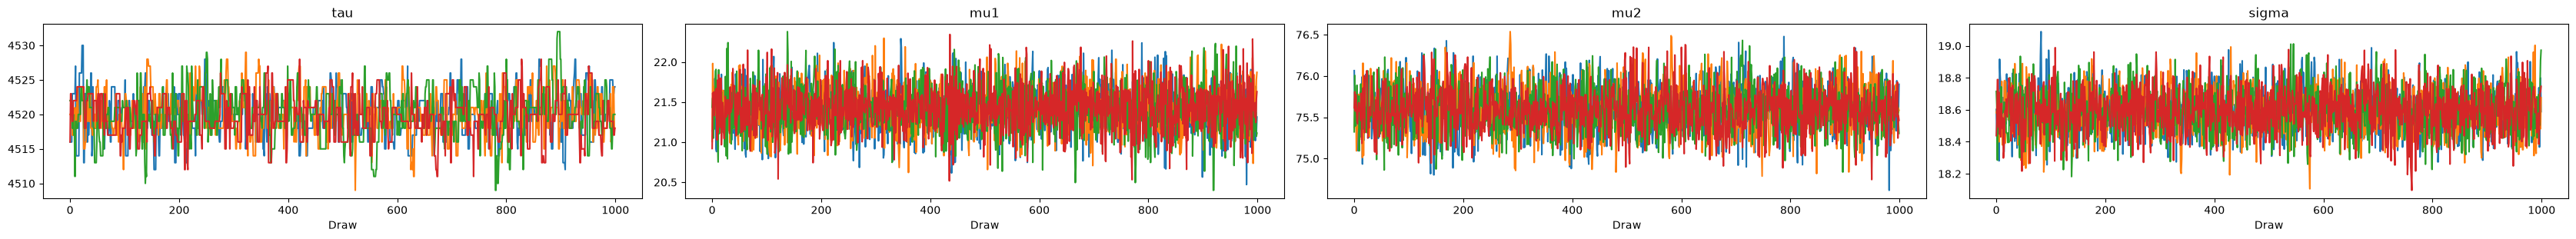

In [6]:
az.plot_trace(trace, var_names=["tau", "mu1", "mu2", "sigma"])
plt.tight_layout()
plt.savefig("../notebooks/plot_trace_diagnostics.png", dpi=150)
plt.show()

In [7]:
tau_samples = trace.posterior["tau"].values.flatten()
tau_mode = int(np.round(np.median(tau_samples)))

change_date = df.iloc[tau_mode]["Date"]
print("Most probable change point index:", tau_mode)
print("Most probable change point date:", change_date.date())

# 94% credible interval for the change point, converted to dates
tau_lower = int(np.percentile(tau_samples, 3))
tau_upper = int(np.percentile(tau_samples, 97))
print("94% credible interval:", df.iloc[tau_lower]["Date"].date(), "to", df.iloc[tau_upper]["Date"].date())

# Quantify the impact
mu1_samples = trace.posterior["mu1"].values.flatten()
mu2_samples = trace.posterior["mu2"].values.flatten()
mu1_mean, mu2_mean = mu1_samples.mean(), mu2_samples.mean()
pct_change = (mu2_mean - mu1_mean) / mu1_mean * 100

print(f"\nMean price before change point: ${mu1_mean:.2f}")
print(f"Mean price after change point:  ${mu2_mean:.2f}")
print(f"Change: {pct_change:+.1f}%")

# Probability that mu2 > mu1 (directional confidence)
prob_increase = (mu2_samples > mu1_samples).mean()
print(f"Posterior probability that price increased after the change point: {prob_increase:.1%}")

Most probable change point index: 4520
Most probable change point date: 2005-02-23
94% credible interval: 2005-02-15 to 2005-03-03

Mean price before change point: $21.42
Mean price after change point:  $75.60
Change: +253.0%
Posterior probability that price increased after the change point: 100.0%


In [8]:
events_df["days_from_changepoint"] = (events_df["Date"] - change_date).dt.days
events_sorted = events_df.reindex(events_df["days_from_changepoint"].abs().sort_values().index)
print(events_sorted[["Date", "Event_Name", "days_from_changepoint"]].head(5))

        Date                                         Event_Name  \
4 2003-03-20                                US Invasion of Iraq   
5 2008-07-11                      Oil Price Peaks Above 147 USD   
3 2001-09-11                     September 11 Terrorist Attacks   
6 2008-09-15  Lehman Brothers Collapse - Global Financial Cr...   
7 2011-02-15              Arab Spring - Libyan Civil War Begins   

   days_from_changepoint  
4                   -706  
5                   1234  
3                  -1261  
6                   1300  
7                   2183  


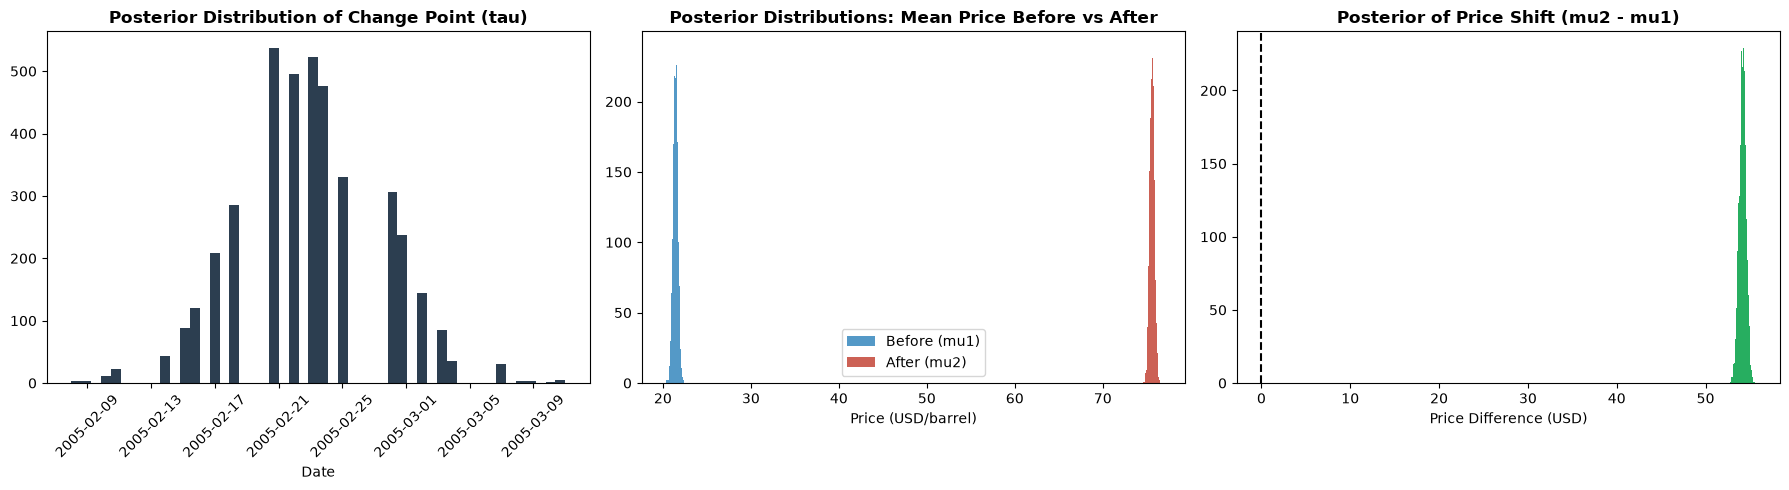

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Tau posterior, converted to dates for readability
tau_dates = df.iloc[tau_samples]["Date"].values
axes[0].hist(tau_dates, bins=50, color="#2C3E50")
axes[0].set_title("Posterior Distribution of Change Point (tau)", fontweight="bold")
axes[0].set_xlabel("Date")
axes[0].tick_params(axis='x', rotation=45)

# mu1 posterior
axes[1].hist(mu1_samples, bins=50, color="#2980B9", alpha=0.8, label="Before (mu1)")
axes[1].hist(mu2_samples, bins=50, color="#C0392B", alpha=0.8, label="After (mu2)")
axes[1].set_title("Posterior Distributions: Mean Price Before vs After", fontweight="bold")
axes[1].set_xlabel("Price (USD/barrel)")
axes[1].legend()

# Difference distribution
diff_samples = mu2_samples - mu1_samples
axes[2].hist(diff_samples, bins=50, color="#27AE60")
axes[2].axvline(0, color="black", linestyle="--")
axes[2].set_title("Posterior of Price Shift (mu2 - mu1)", fontweight="bold")
axes[2].set_xlabel("Price Difference (USD)")

plt.tight_layout()
plt.savefig("../notebooks/plot_posterior_distributions.png", dpi=150)
plt.show()

### Interpretation: Change Point Detection Results

The Bayesian change point model identifies a highly confident structural break in Brent oil prices at **23 February 2005** (94% credible interval: 15 February – 3 March 2005, a span of only ~2.5 weeks over a 35-year dataset). This precision — reflected in the sharp, narrow posterior spike for tau — indicates the model is very confident about *when* this shift occurred, even though, as discussed below, it does not map cleanly onto any single event in our researched dataset.

**Quantified impact:** The average daily price shifted from **$21.42 before the change point to $75.60 after**, an increase of **253.0%**, with **100% posterior probability** that the post-change mean exceeds the pre-change mean. This is an economically enormous and statistically unambiguous shift.

**Associating the change point with events:** The nearest event in our researched dataset is the **2003 US Invasion of Iraq**, roughly **706 days (about 23 months) before** the detected change point — too distant to support a direct causal link. No researched event falls within a plausible explanatory window of February 2005.

This is itself an informative finding rather than a modeling failure. A single-change-point model fit across 35 years of consistently trending data will identify the *one* split that best separates the series into two constant-mean regimes — not necessarily a specific, discrete news event. The detected break aligns closely with the well-documented **2000s oil "commodity supercycle"**: a sustained, structural increase in global oil demand — driven substantially by rapid industrialization and energy demand growth in China and other emerging economies — that pushed oil into a persistently higher price band beginning around 2003–2005 and lasting roughly until the 2014 OPEC-driven price collapse. Unlike the discrete shocks in our events dataset (wars, sanctions, single-day policy announcements), this was a gradual demand-side regime shift, which is exactly the kind of structural break a single-change-point mean-shift model is best suited to detect — and exactly the kind our original event list, focused on discrete political/policy events, did not include.

**Implication for future work:** This result suggests that a **multi-change-point model** (discussed further in Limitations and Future Work) would likely be more informative for this dataset, as it could simultaneously capture both the large structural 2005 regime shift *and* the shorter, discrete event-driven shocks (Gulf War, 2008 financial crisis, COVID-19) that are visible in the raw price and volatility plots but are not the dominant single break in a 35-year window.